In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car data.csv to car data.csv


In [3]:
df = pd.read_csv("car data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 301
Columns : 9


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [9]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [10]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 2


In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


In [13]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,299.000000,299.000000,299.000000,299.000000,299.000000
mean,2013.615385,4.589632,7.541037,36916.752508,0.043478
std,2.896868,4.984240,8.566332,39015.170352,0.248720
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.850000,1.200000,15000.000000,0.000000
50%,2014.000000,3.510000,6.100000,32000.000000,0.000000
75%,2016.000000,6.000000,9.840000,48883.500000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [14]:
print(df["Fuel_Type"].unique())

['Petrol' 'Diesel' 'CNG']


In [15]:
print(df["Selling_type"].unique())

['Dealer' 'Individual']


In [16]:
print(df["Transmission"].unique())

['Manual' 'Automatic']


In [17]:
CURRENT_YEAR = 2026
df["Car_Age"] = CURRENT_YEAR - df["Year"]

In [18]:
df.drop("Year", axis=1, inplace=True)

In [19]:
df.head()

,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [20]:
car_names = df["Car_Name"]

In [21]:
df.drop("Car_Name", axis=1, inplace=True)

In [22]:
fuel_encoder = LabelEncoder()
df["Fuel_Type"] = fuel_encoder.fit_transform(df["Fuel_Type"])

In [23]:
selling_encoder = LabelEncoder()
df["Selling_type"] = selling_encoder.fit_transform(df["Selling_type"])

In [24]:
transmission_encoder = LabelEncoder()
df["Transmission"] = transmission_encoder.fit_transform(df["Transmission"])

In [25]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,12
1,4.75,9.54,43000,1,0,1,0,13
2,7.25,9.85,6900,2,0,1,0,9
3,2.85,4.15,5200,2,0,1,0,15
4,4.60,6.87,42450,1,0,1,0,12


In [27]:
df.to_csv("Clean_Car_Data.csv", index=False)
print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [28]:
## EDA

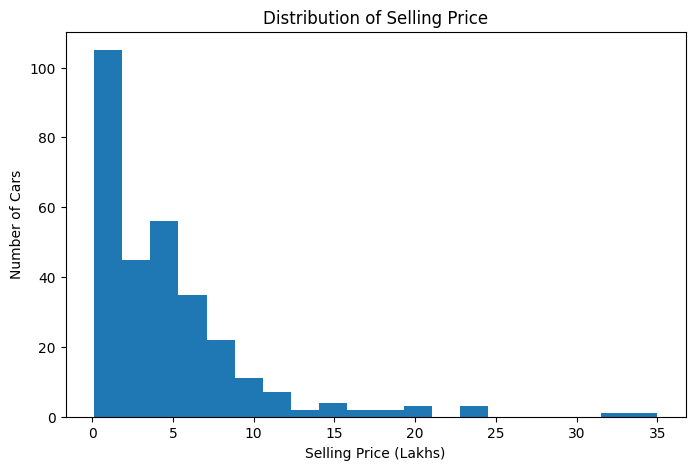

In [29]:
plt.figure(figsize=(8,5))
plt.hist(df["Selling_Price"], bins=20)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.show()

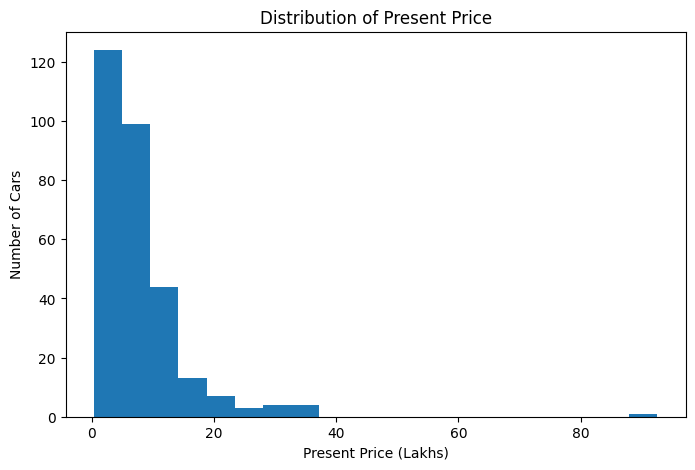

In [30]:
plt.figure(figsize=(8,5))
plt.hist(df["Present_Price"], bins=20)
plt.title("Distribution of Present Price")
plt.xlabel("Present Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.show()

In [31]:
fuel_counts = df["Fuel_Type"].value_counts()
print(fuel_counts)

Fuel_Type
2    239
1     58
0      2
Name: count, dtype: int64


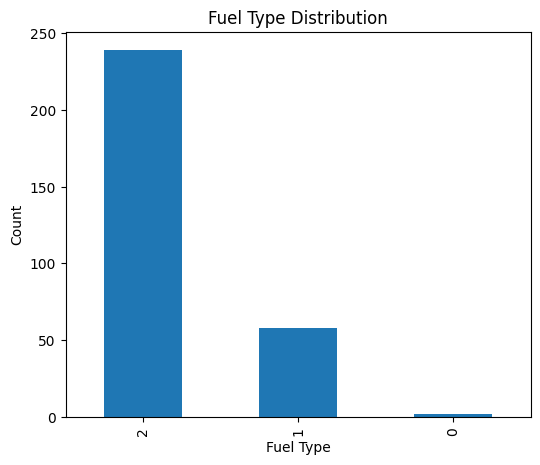

In [32]:
plt.figure(figsize=(6,5))
fuel_counts.plot(kind="bar")
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

In [33]:
selling_counts = df["Selling_type"].value_counts()
print(selling_counts)

Selling_type
0    193
1    106
Name: count, dtype: int64


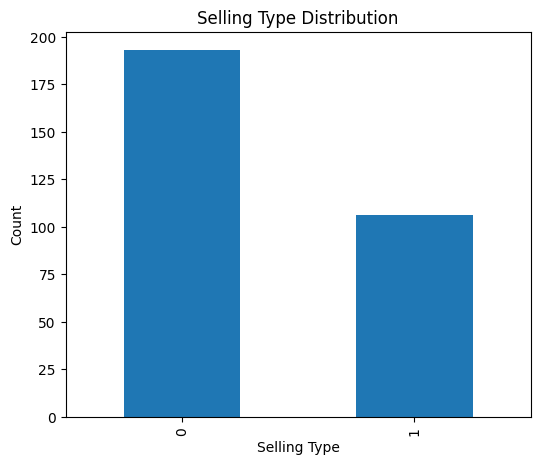

In [34]:
plt.figure(figsize=(6,5))
selling_counts.plot(kind="bar")
plt.title("Selling Type Distribution")
plt.xlabel("Selling Type")
plt.ylabel("Count")
plt.show()

In [35]:
transmission_counts = df["Transmission"].value_counts()
print(transmission_counts)

Transmission
1    260
0     39
Name: count, dtype: int64


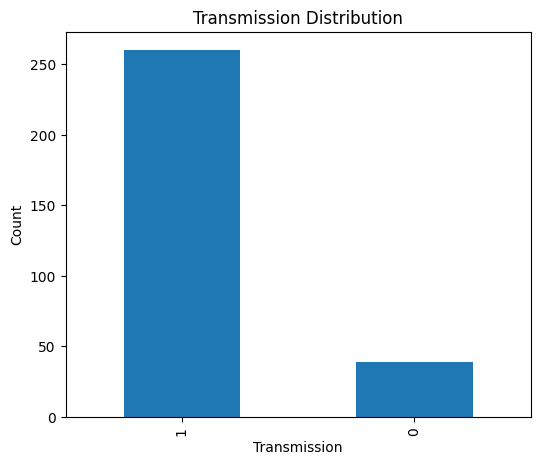

In [36]:
plt.figure(figsize=(6,5))
transmission_counts.plot(kind="bar")
plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.show()

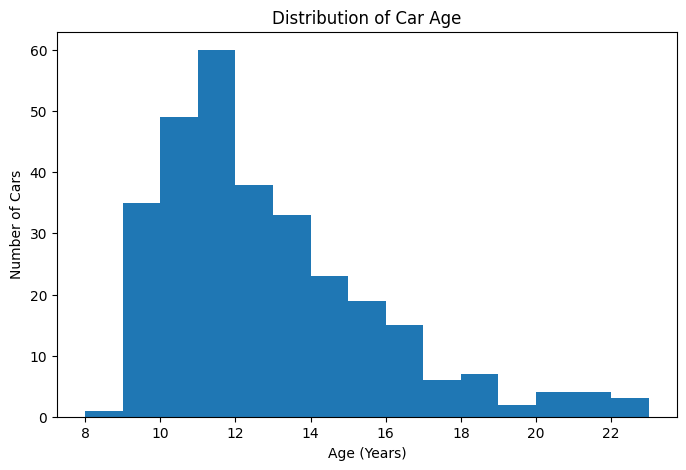

In [37]:
plt.figure(figsize=(8,5))
plt.hist(df["Car_Age"], bins=15)
plt.title("Distribution of Car Age")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Cars")
plt.show()

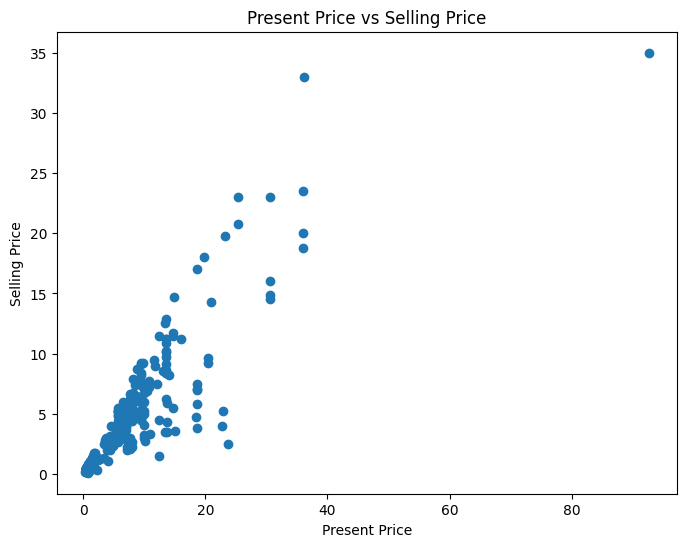

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Present_Price"],
    df["Selling_Price"]
)
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

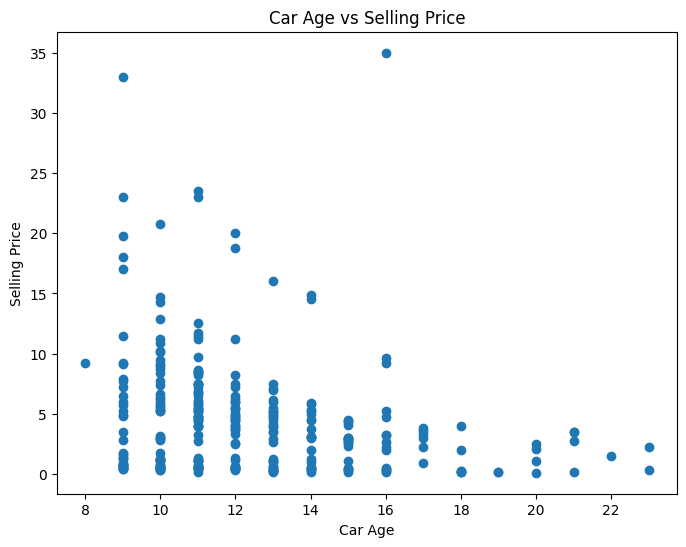

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Car_Age"],
    df["Selling_Price"]
)
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

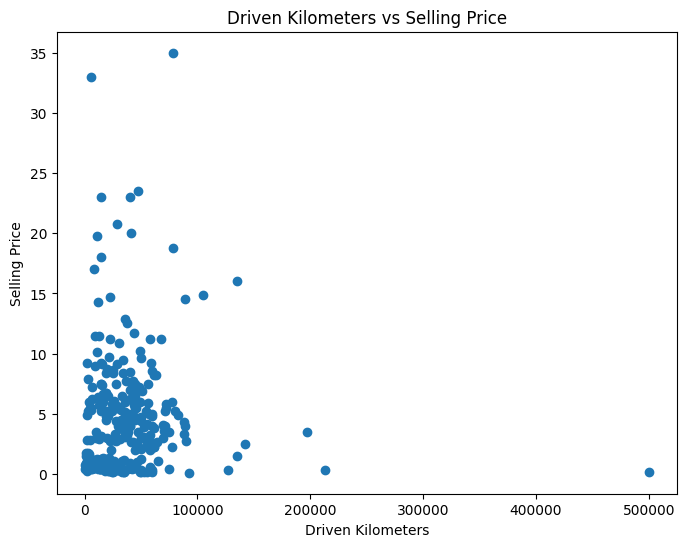

In [40]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Driven_kms"],
    df["Selling_Price"]
)
plt.title("Driven Kilometers vs Selling Price")
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")
plt.show()

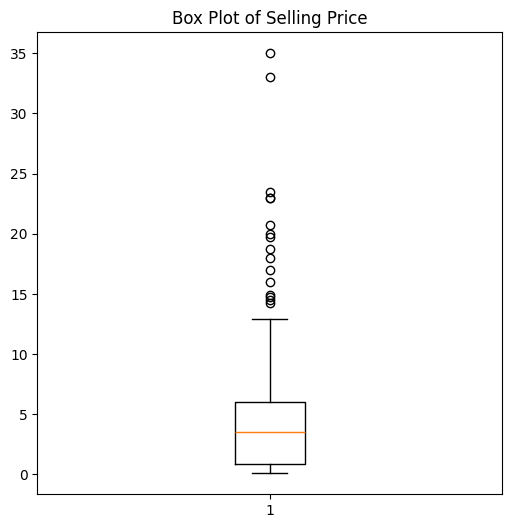

In [41]:
plt.figure(figsize=(6,6))
plt.boxplot(df["Selling_Price"])
plt.title("Box Plot of Selling Price")
plt.show()

In [42]:
correlation = df.corr()
print(correlation)

               Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
Selling_Price       1.000000       0.876305    0.028566  -0.500292   
Present_Price       0.876305       1.000000    0.205224  -0.431887   
Driven_kms          0.028566       0.205224    1.000000  -0.167287   
Fuel_Type          -0.500292      -0.431887   -0.167287   1.000000   
Selling_type       -0.553851      -0.511779   -0.101030   0.347922   
Transmission       -0.348869      -0.334326   -0.163881   0.068618   
Owner              -0.087880       0.009948    0.089367   0.054174   
Car_Age            -0.234369       0.053167    0.525714   0.046210   

               Selling_type  Transmission     Owner   Car_Age  
Selling_Price     -0.553851     -0.348869 -0.087880 -0.234369  
Present_Price     -0.511779     -0.334326  0.009948  0.053167  
Driven_kms        -0.101030     -0.163881  0.089367  0.525714  
Fuel_Type          0.347922      0.068618  0.054174  0.046210  
Selling_type       1.000000      0.058669  0.1236

In [43]:
highest = df.sort_values("Selling_Price",ascending=False)
highest.head(10)

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
86,35.00,92.60,78000,1,0,1,0,16
64,33.00,36.23,6000,1,0,0,0,9
63,23.50,35.96,47000,1,0,0,0,11
82,23.00,25.39,15000,1,0,0,0,9
51,23.00,30.61,40000,1,0,0,0,11
96,20.75,25.39,29000,1,0,0,0,10
59,19.99,35.96,41000,1,0,0,0,12
66,19.75,23.15,11000,2,0,0,0,9
62,18.75,35.96,78000,1,0,0,0,12
52,18.00,19.77,15000,1,0,0,0,9


In [44]:
lowest = df.sort_values("Selling_Price")
lowest.head(10)

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
200,0.10,0.750,92233,2,1,1,0,20
199,0.12,0.580,53000,2,1,1,0,19
198,0.15,0.570,35000,2,1,1,1,15
197,0.16,0.510,33000,2,1,1,0,16
196,0.17,0.520,500000,2,1,0,0,18
195,0.18,0.320,35000,2,1,1,0,11
193,0.20,0.650,24000,2,1,1,1,13
189,0.20,0.570,55000,2,1,1,0,21
194,0.20,0.787,50000,2,1,1,0,18
192,0.20,0.750,49000,2,1,1,1,19


In [45]:
print("Average Selling Price:")
print(df["Selling_Price"].mean())

Average Selling Price:
4.589632107023411


In [46]:
print("Maximum Selling Price:")
print(df["Selling_Price"].max())

Maximum Selling Price:
35.0


In [47]:
print("Minimum Selling Price:")
print(df["Selling_Price"].min())

Minimum Selling Price:
0.1


In [48]:
print("Average Present Price:")
print(df["Present_Price"].mean())

Average Present Price:
7.541036789297658


In [49]:
print("Average Car Age:")
print(df["Car_Age"].mean())

Average Car Age:
12.384615384615385


In [50]:
print("="*50)
print("KEY INSIGHTS")
print("="*50)
print("Total Cars:", len(df))
print("Average Selling Price:", round(df["Selling_Price"].mean(),2))
print("Average Present Price:", round(df["Present_Price"].mean(),2))
print("Maximum Selling Price:", df["Selling_Price"].max())
print("Minimum Selling Price:", df["Selling_Price"].min())
print("Average Car Age:", round(df["Car_Age"].mean(),2))
print("="*50)

KEY INSIGHTS
Total Cars: 299
Average Selling Price: 4.59
Average Present Price: 7.54
Maximum Selling Price: 35.0
Minimum Selling Price: 0.1
Average Car Age: 12.38


In [53]:
## ML Model

In [54]:
# Features (Independent Variables)
X = df.drop("Selling_Price", axis=1)
# Target (Dependent Variable)
y = df["Selling_Price"]

In [55]:
X.head()

,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,5.59,27000,2,0,1,0,12
1,9.54,43000,1,0,1,0,13
2,9.85,6900,2,0,1,0,9
3,4.15,5200,2,0,1,0,15
4,6.87,42450,1,0,1,0,12


In [56]:
y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [57]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (299, 7)
Target Shape: (299,)


In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [59]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (239, 7)
Testing Features : (60, 7)
Training Labels : (239,)
Testing Labels : (60,)


In [60]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [61]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [62]:
y_pred = model.predict(X_test)

In [63]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
comparison.head(15)

,Actual Price,Predicted Price
0,8.99,9.4393
1,8.35,8.2770
2,0.45,0.4401
3,7.45,6.8680
4,5.25,16.5640
5,5.25,5.3275
6,5.85,6.8375
7,1.15,1.1800
8,9.25,7.9060
9,0.38,0.2820


In [64]:
sample = X.iloc[[0]]
prediction = model.predict(sample)
print("Predicted Selling Price:", prediction[0])
print("Actual Selling Price:", y.iloc[0])

Predicted Selling Price: 3.590000000000002
Actual Selling Price: 3.35


In [65]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance

,Feature,Importance
0,Present_Price,0.909067
6,Car_Age,0.068192
1,Driven_kms,0.014157
4,Transmission,0.004800
3,Selling_type,0.002028
2,Fuel_Type,0.001747
5,Owner,0.000009


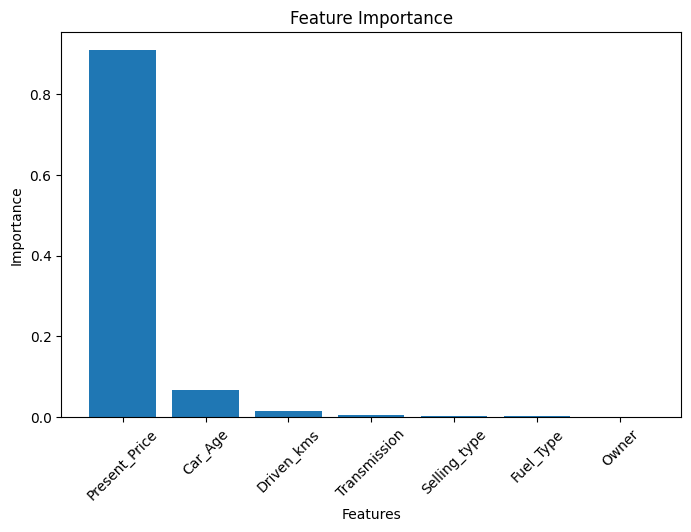

In [66]:
plt.figure(figsize=(8,5))
plt.bar(
    importance["Feature"],
    importance["Importance"]
)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [67]:
print("Top 5 Important Features")
importance.head()

Top 5 Important Features


,Feature,Importance
0,Present_Price,0.909067
6,Car_Age,0.068192
1,Driven_kms,0.014157
4,Transmission,0.004800
3,Selling_type,0.002028


In [68]:
predictions = model.predict(X_test[:10])
print(predictions)

[ 9.4393  8.277   0.4401  6.868  16.564   5.3275  6.8375  1.18    7.906
  0.282 ]


In [69]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
results.head(20)

,Actual,Predicted
0,8.99,9.4393
1,8.35,8.2770
2,0.45,0.4401
3,7.45,6.8680
4,5.25,16.5640
5,5.25,5.3275
6,5.85,6.8375
7,1.15,1.1800
8,9.25,7.9060
9,0.38,0.2820


In [70]:
print(model)

RandomForestRegressor(random_state=42)


In [71]:
## Model Evalution, Prediction & Saving

In [72]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 1.412970000000001


In [73]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 11.15111805666667


In [74]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 3.3393289829944384


In [75]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.5673377331701552


In [76]:
print("="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")
print("="*50)

MODEL EVALUATION
MAE  : 1.4130
MSE  : 11.1511
RMSE : 3.3393
R² Score : 0.5673


In [77]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
comparison.head(20)

,Actual Price,Predicted Price
0,8.99,9.4393
1,8.35,8.2770
2,0.45,0.4401
3,7.45,6.8680
4,5.25,16.5640
5,5.25,5.3275
6,5.85,6.8375
7,1.15,1.1800
8,9.25,7.9060
9,0.38,0.2820


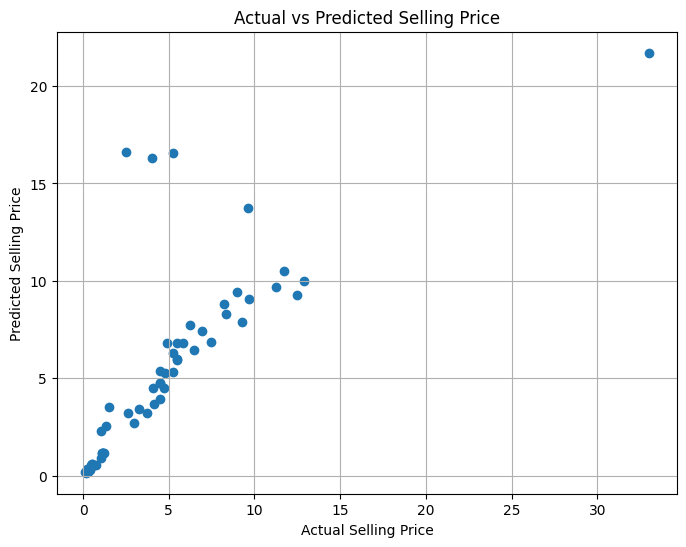

In [78]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred
)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()

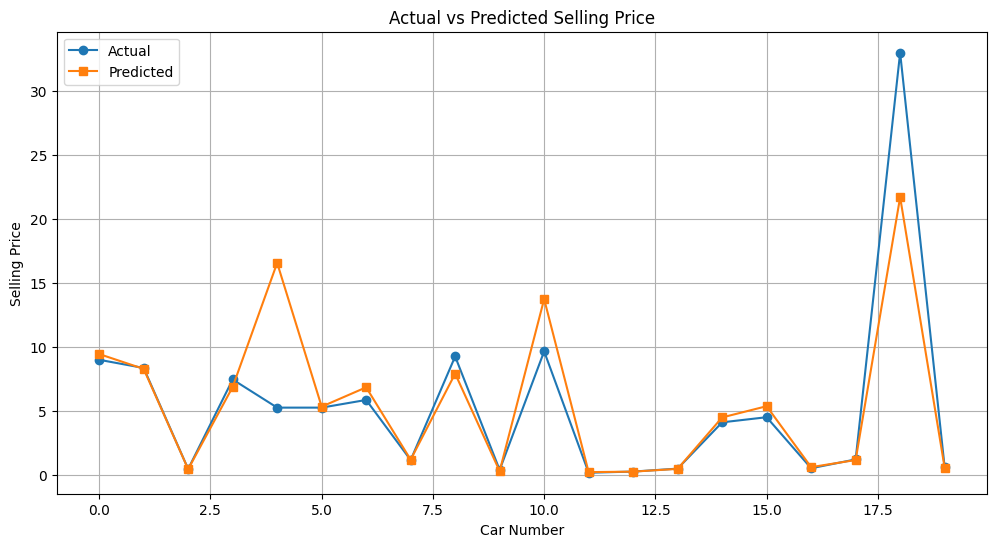

In [79]:
plt.figure(figsize=(12,6))
plt.plot(
    comparison["Actual Price"].values[:20],
    label="Actual",
    marker="o"
)
plt.plot(
    comparison["Predicted Price"].values[:20],
    label="Predicted",
    marker="s"
)
plt.title("Actual vs Predicted Selling Price")
plt.xlabel("Car Number")
plt.ylabel("Selling Price")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
residuals = y_test - y_pred
print(residuals.head())

283    -0.4493
267     0.0730
166     0.0099
9       0.5820
78    -11.3140
Name: Selling_Price, dtype: float64


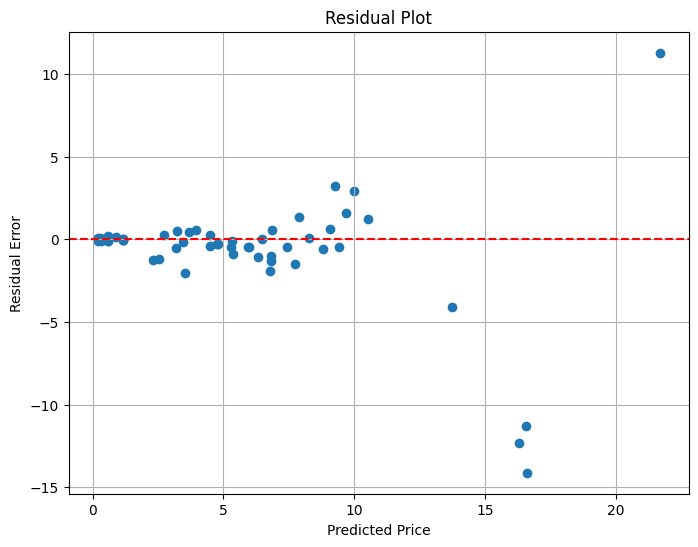

In [81]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_pred,
    residuals
)
plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)
plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [82]:
joblib.dump(model, "Car_Price_Prediction_Model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [83]:
df.to_csv("Clean_Car_Data.csv", index=False)
print("Clean dataset saved successfully!")

Clean dataset saved successfully!


In [84]:
from google.colab import files
files.download("Car_Price_Prediction_Model.pkl")
files.download("Clean_Car_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
sample = [[
    8.50,      # Present Price
    35000,     # Driven Kilometers
    2,         # Fuel Type (Petrol/Diesel/CNG encoded)
    0,         # Selling Type (Dealer/Individual encoded)
    1,         # Transmission (Automatic/Manual encoded)
    0,         # Owner
    5          # Car Age
]]
prediction = model.predict(sample)
print("Predicted Selling Price (Lakhs):", round(prediction[0], 2))

Predicted Selling Price (Lakhs): 6.76


In [86]:
print("="*50)
print("CAR PRICE PREDICTION MODEL SUMMARY")
print("="*50)
print("Algorithm Used : Random Forest Regressor")
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))
print("Number of Features :", X.shape[1])
print("Model Trained Successfully")
print("Prediction Completed Successfully")
print("="*50)

CAR PRICE PREDICTION MODEL SUMMARY
Algorithm Used : Random Forest Regressor
Training Samples : 239
Testing Samples : 60
Number of Features : 7
Model Trained Successfully
Prediction Completed Successfully
